In [1]:
# ============================================
# CELLULE 1 — Installation des bibliothèques
# ============================================
!pip install pandas mysql-connector-python sqlalchemy scikit-learn joblib flask flask-cors matplotlib seaborn pyodbc

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# ============================================
# CELLULE 2 — Imports et Connexions
# ============================================
import pandas as pd
import numpy as np
import mysql.connector
import sqlalchemy
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Connexion MySQL
conn_mysql = mysql.connector.connect(
    host="localhost", user="root", password="", database="soc_dashboard"
)

# Connexion SQL Server
engine_ssms = sqlalchemy.create_engine(
    'mssql+pyodbc://localhost\\SQLEXPRESS/SOC_DW?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes'
)

print("✅ Connexion MySQL OK")
print("✅ Connexion SQL Server OK")

✅ Connexion MySQL OK
✅ Connexion SQL Server OK


In [5]:
# ============================================
# CELLULE 3 — EXTRACT
# ============================================

# 1. Extraire depuis fichier XLS Jira
tables = pd.read_html("Jira 2026-03-23T18_01_56+0100.xls")
df_jira = tables[1]  # Table avec les vrais tickets
df_jira.columns = ['jira_key', 'summary', 'created', 'outage_start', 'assignee', 'client']
df_jira = df_jira.dropna(subset=['jira_key', 'client'])
print(f"✅ Jira XLS : {len(df_jira)} tickets")

# 2. Extraire depuis MySQL — nouvelles tables
df_users = pd.read_sql("SELECT * FROM users", conn_mysql)
df_clients = pd.read_sql("SELECT * FROM clients", conn_mysql)
df_tickets = pd.read_sql("SELECT t.*, c.name as client_name, u.full_name as assignee_name FROM tickets t LEFT JOIN clients c ON t.client_id = c.id LEFT JOIN users u ON t.assignee_id = u.id", conn_mysql)
df_time_entries = pd.read_sql("SELECT te.*, c.name as client_name, u.full_name as user_name FROM time_entries te LEFT JOIN clients c ON te.client_id = c.id LEFT JOIN users u ON te.user_id = u.id", conn_mysql)
df_rules = pd.read_sql("SELECT r.*, c.name as client_name FROM rules r LEFT JOIN clients c ON r.client_id = c.id", conn_mysql)

print(f"✅ Users : {len(df_users)}")
print(f"✅ Clients : {len(df_clients)}")
print(f"✅ Tickets : {len(df_tickets)}")
print(f"✅ Time Entries : {len(df_time_entries)}")
print(f"✅ Rules : {len(df_rules)}")

print(f"\n📊 Tickets par client :")
print(df_tickets['client_name'].value_counts())
print(f"\n👥 Tickets par assignee :")
print(df_tickets['assignee_name'].value_counts())

✅ Jira XLS : 1510 tickets
✅ Users : 10
✅ Clients : 21
✅ Tickets : 1510
✅ Time Entries : 1510
✅ Rules : 16

📊 Tickets par client :
client_name
STT          690
SMBC         414
Devops       132
GEN          128
LGIM          40
MILL          26
VEGGO         26
FIERA         19
LIFESTAR       8
ALLIANZ        6
AIG            6
MUFG           5
ICC            4
CARMIGNAC      3
NOCHU          2
MIZUHO         1
Name: count, dtype: int64

👥 Tickets par assignee :
assignee_name
SOCUSER                   1487
Khaled KSIBI                 6
Ahmed Yosreddine SAMTI       6
Wissem SAADLI                2
Yassine BEN AMARA            2
Zied MOKNI                   2
Amir NAMOUCHI                2
Sabeur FRADJ                 1
Mohamed Ghaith BASLY         1
Zeineb HAMMAMI               1
Name: count, dtype: int64


✅ Transform réussi : 1510 tickets

📊 Types :
ticket_type
SAAS    1510
Name: count, dtype: int64

📅 Période : 1970-01-01 → 2026-03-23

📊 Clients uniques : 16

📊 Assignees uniques : 10


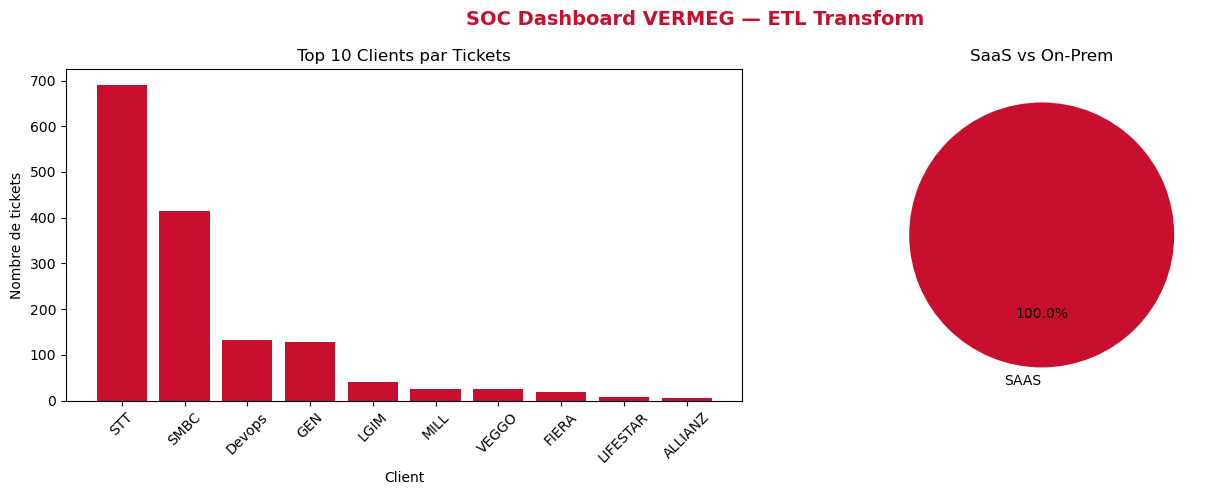

✅ Graphiques sauvegardés !


In [7]:
# ============================================
# CELLULE 4 — TRANSFORM
# ============================================

# 1. Nettoyer et transformer les données Jira
df = df_jira.copy()

# Convertir les dates
df['created'] = pd.to_datetime(df['created'], format='%d/%b/%y %I:%M %p', errors='coerce')
df['outage_start'] = pd.to_datetime(df['outage_start'], format='%d/%b/%y %I:%M %p', errors='coerce')

# Ajouter colonnes calculées
df['hours_logged'] = 0.25
df['ticket_type'] = df['client'].apply(lambda x: 'ONPREM' if x in ['GIS','BDO','CDO','DO','EIP'] else 'SAAS')
df['date'] = df['outage_start'].dt.date
df['day_of_week'] = df['outage_start'].dt.dayofweek
df['month'] = df['outage_start'].dt.month
df['week'] = df['outage_start'].dt.isocalendar().week.astype(int)
df['year'] = df['outage_start'].dt.year

# Trier par date
df = df.sort_values('outage_start').reset_index(drop=True)

print(f"✅ Transform réussi : {len(df)} tickets")
print(f"\n📊 Types :")
print(df['ticket_type'].value_counts())
print(f"\n📅 Période : {df['date'].min()} → {df['date'].max()}")
print(f"\n📊 Clients uniques : {df['client'].nunique()}")
print(f"\n📊 Assignees uniques : {df['assignee'].nunique()}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SOC Dashboard VERMEG — ETL Transform', fontsize=14, fontweight='bold', color='#C8102E')

# Bar chart tickets par client
client_counts = df['client'].value_counts().head(10)
axes[0].bar(client_counts.index, client_counts.values, color='#C8102E')
axes[0].set_title('Top 10 Clients par Tickets')
axes[0].set_xlabel('Client')
axes[0].set_ylabel('Nombre de tickets')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart SaaS vs OnPrem
type_counts = df['ticket_type'].value_counts()
axes[1].pie(type_counts.values, labels=type_counts.index, colors=['#C8102E', '#0f3460'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('SaaS vs On-Prem')

plt.tight_layout()
plt.savefig('transform_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques sauvegardés !")

In [11]:
# ============================================
# CELLULE 5 — LOAD Star Schema SQL Server
# ============================================

# Supprimer les anciennes tables dans le bon ordre
with engine_ssms.connect() as conn:
    tables_to_drop = ['fact_time_entries', 'skipped_tickets', 'rules',
                      'time_entries', 'tickets', 'dim_assignees', 
                      'dim_clients', 'dim_dates', 'clients', 'users']
    for t in tables_to_drop:
        conn.execute(sqlalchemy.text(f"IF OBJECT_ID('{t}') IS NOT NULL DROP TABLE {t}"))
    conn.commit()
print("✅ Anciennes tables supprimées")

# DIM_CLIENTS
dim_clients = pd.DataFrame({'client_name': df['client'].unique()}).reset_index()
dim_clients.columns = ['client_id', 'client_name']
dim_clients['ticket_type'] = dim_clients['client_name'].apply(
    lambda x: 'ONPREM' if x in ['GIS','BDO','CDO','DO','EIP'] else 'SAAS')
dim_clients.to_sql('dim_clients', engine_ssms, if_exists='replace', index=False)
print(f"✅ dim_clients : {len(dim_clients)} clients")

# DIM_ASSIGNEES
dim_assignees = pd.DataFrame({'assignee_name': df['assignee'].unique()}).reset_index()
dim_assignees.columns = ['assignee_id', 'assignee_name']
dim_assignees.to_sql('dim_assignees', engine_ssms, if_exists='replace', index=False)
print(f"✅ dim_assignees : {len(dim_assignees)} assignees")

# DIM_DATES
dim_dates = pd.DataFrame({'date': df['date'].unique()})
dim_dates = dim_dates.dropna().reset_index()
dim_dates.columns = ['date_id', 'date']
dim_dates['date'] = pd.to_datetime(dim_dates['date'])
dim_dates['year'] = dim_dates['date'].dt.year
dim_dates['month'] = dim_dates['date'].dt.month
dim_dates['day'] = dim_dates['date'].dt.day
dim_dates['weekday'] = dim_dates['date'].dt.day_name()
dim_dates['quarter'] = dim_dates['date'].dt.quarter
dim_dates.to_sql('dim_dates', engine_ssms, if_exists='replace', index=False)
print(f"✅ dim_dates : {len(dim_dates)} dates")

# FACT_TIME_ENTRIES
fact = df.copy()
fact['date'] = pd.to_datetime(fact['date'])
dim_dates['date'] = pd.to_datetime(dim_dates['date'])

# Joindre avec les dimensions
fact = fact.merge(dim_clients[['client_id','client_name']], left_on='client', right_on='client_name', how='left')
fact = fact.merge(dim_assignees[['assignee_id','assignee_name']], left_on='assignee', right_on='assignee_name', how='left')
fact = fact.merge(dim_dates[['date_id','date']], on='date', how='left')

fact_final = fact[['jira_key', 'summary', 'client_id', 'assignee_id', 'date_id',
                   'hours_logged', 'ticket_type', 'outage_start']].copy()
fact_final.to_sql('fact_time_entries', engine_ssms, if_exists='replace', index=False)
print(f"✅ fact_time_entries : {len(fact_final)} entrées")
print("\n🎉 Star Schema chargé dans SQL Server !")

✅ Anciennes tables supprimées
✅ dim_clients : 16 clients
✅ dim_assignees : 10 assignees
✅ dim_dates : 56 dates
✅ fact_time_entries : 1510 entrées

🎉 Star Schema chargé dans SQL Server !


In [13]:
# ============================================
# CELLULE 6 — Primary Keys + Foreign Keys SSMS
# ============================================

with engine_ssms.connect() as conn:
    # Rendre les colonnes NOT NULL
    pks_notnull = [
        "ALTER TABLE dim_clients ALTER COLUMN client_id INT NOT NULL",
        "ALTER TABLE dim_assignees ALTER COLUMN assignee_id INT NOT NULL",
        "ALTER TABLE dim_dates ALTER COLUMN date_id INT NOT NULL",
        "ALTER TABLE fact_time_entries ALTER COLUMN client_id INT",
        "ALTER TABLE fact_time_entries ALTER COLUMN assignee_id INT",
        "ALTER TABLE fact_time_entries ALTER COLUMN date_id INT",
    ]
    for sql in pks_notnull:
        try:
            conn.execute(sqlalchemy.text(sql))
        except Exception as e:
            print(f"⚠️ {e}")
    conn.commit()

    # Primary Keys
    pks = [
        "ALTER TABLE dim_clients ADD CONSTRAINT PK_dim_clients PRIMARY KEY (client_id)",
        "ALTER TABLE dim_assignees ADD CONSTRAINT PK_dim_assignees PRIMARY KEY (assignee_id)",
        "ALTER TABLE dim_dates ADD CONSTRAINT PK_dim_dates PRIMARY KEY (date_id)",
    ]
    for sql in pks:
        try:
            conn.execute(sqlalchemy.text(sql))
            print(f"✅ PK: {sql.split('CONSTRAINT ')[1].split(' ')[0]}")
        except Exception as e:
            print(f"⚠️ {e}")
    conn.commit()

    # Foreign Keys
    fks = [
        "ALTER TABLE fact_time_entries ADD CONSTRAINT FK_fact_clients FOREIGN KEY (client_id) REFERENCES dim_clients(client_id)",
        "ALTER TABLE fact_time_entries ADD CONSTRAINT FK_fact_assignees FOREIGN KEY (assignee_id) REFERENCES dim_assignees(assignee_id)",
        "ALTER TABLE fact_time_entries ADD CONSTRAINT FK_fact_dates FOREIGN KEY (date_id) REFERENCES dim_dates(date_id)",
    ]
    for sql in fks:
        try:
            conn.execute(sqlalchemy.text(sql))
            print(f"✅ FK: {sql.split('CONSTRAINT ')[1].split(' ')[0]}")
        except Exception as e:
            print(f"⚠️ {e}")
    conn.commit()

print("\n🎉 PK + FK Star Schema créées !")

✅ PK: PK_dim_clients
✅ PK: PK_dim_assignees
✅ PK: PK_dim_dates
✅ FK: FK_fact_clients
✅ FK: FK_fact_assignees
✅ FK: FK_fact_dates

🎉 PK + FK Star Schema créées !


In [15]:
# ============================================
# CELLULE 7 — COMPOSANTE IA — Prédiction de charge
# ============================================
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import joblib

# Préparer les données
df_model = df.copy()
df_model['day_of_week'] = pd.to_datetime(df_model['outage_start']).dt.dayofweek
df_model['month'] = pd.to_datetime(df_model['outage_start']).dt.month
df_model['week'] = pd.to_datetime(df_model['outage_start']).dt.isocalendar().week.astype(int)
df_model['date_only'] = pd.to_datetime(df_model['outage_start']).dt.date

# Agrégation par client par jour
df_agg = df_model.groupby(['date_only', 'client', 'day_of_week', 'month', 'week']).size().reset_index(name='ticket_count')

# Encoder les clients
le = LabelEncoder()
df_agg['client_encoded'] = le.fit_transform(df_agg['client'])

X = df_agg[['client_encoded', 'day_of_week', 'month', 'week']]
y = df_agg['ticket_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraîner Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
mae = mean_absolute_error(y_test, model_rf.predict(X_test))
print(f"✅ Random Forest entraîné — MAE : {mae:.2f} tickets/jour")

# Prédiction semaine prochaine
print("\n📊 Prédiction semaine prochaine :")
results = []
for client in sorted(df_agg['client'].unique()):
    client_enc = le.transform([client])[0]
    weekly = sum([model_rf.predict([[client_enc, day, 4, 18]])[0] for day in range(5)])
    results.append({'client': client, 'tickets': round(weekly), 'heures': round(weekly * 0.25, 2)})
    print(f"  {client:<12} : ~{round(weekly)} tickets → {round(weekly * 0.25, 2)}h")

df_pred = pd.DataFrame(results)
print(f"\n📊 Total : {df_pred['tickets'].sum()} tickets — {df_pred['heures'].sum()}h")

# Sauvegarder
joblib.dump(model_rf, 'model_workload.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\n✅ Modèle Random Forest sauvegardé !")

✅ Random Forest entraîné — MAE : 2.31 tickets/jour

📊 Prédiction semaine prochaine :
  AIG          : ~7 tickets → 1.81h
  ALLIANZ      : ~8 tickets → 2.04h
  CARMIGNAC    : ~9 tickets → 2.26h
  Devops       : ~10 tickets → 2.61h
  FIERA        : ~11 tickets → 2.69h
  GEN          : ~12 tickets → 3.1h
  ICC          : ~14 tickets → 3.5h
  LGIM         : ~14 tickets → 3.46h
  LIFESTAR     : ~11 tickets → 2.79h
  MILL         : ~13 tickets → 3.14h
  MIZUHO       : ~12 tickets → 3.12h
  MUFG         : ~13 tickets → 3.13h
  NOCHU        : ~12 tickets → 3.12h
  SMBC         : ~17 tickets → 4.24h
  STT          : ~38 tickets → 9.61h
  VEGGO        : ~5 tickets → 1.27h

📊 Total : 206 tickets — 51.89h

✅ Modèle Random Forest sauvegardé !


✅ Détection d'anomalies terminée !
📊 Jours analysés : 278
⚠️ Anomalies détectées : 13

🚨 Top anomalies :
      date_only client  ticket_count  total_hours
152  2026-02-26    STT            37         9.25
70   2026-02-12    STT            32         8.00
101  2026-02-17    STT            32         8.00
75   2026-02-13    STT            31         7.75
120  2026-02-20    STT            30         7.50
111  2026-02-19    STT            29         7.25
43   2026-02-06    STT            27         6.75
140  2026-02-24    STT            24         6.00
92   2026-02-16    STT            22         5.50
199  2026-03-06    STT            21         5.25


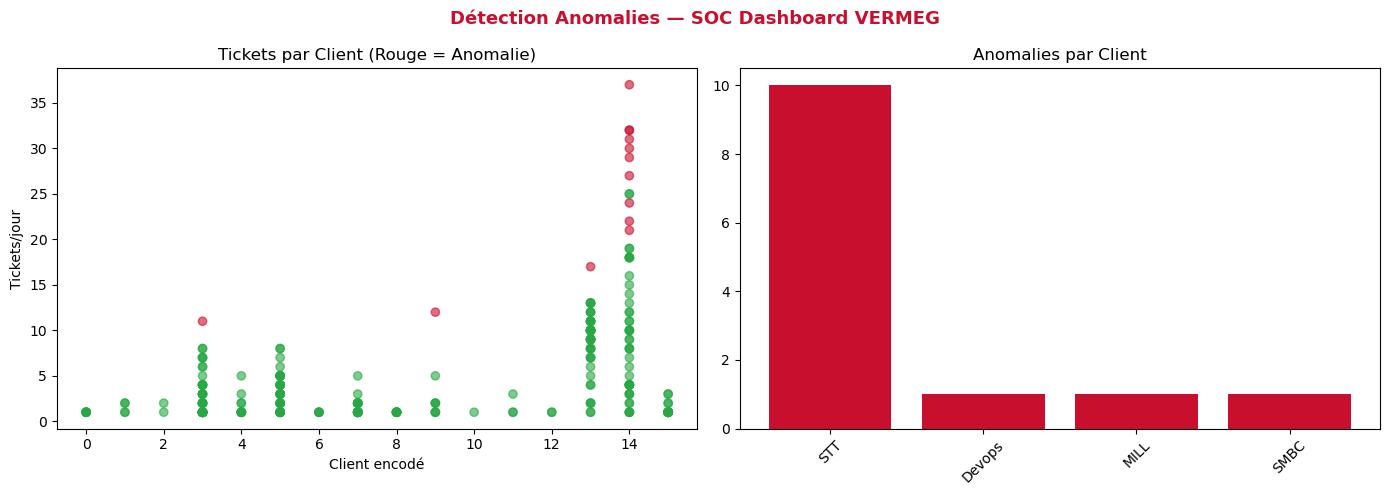


✅ Modèle Isolation Forest sauvegardé !


In [19]:
# ============================================
# CELLULE — COMPOSANTE IA — Détection d'anomalies
# ============================================

# Agrégation par client par jour
df_daily = df_model.groupby(['date_only', 'client']).agg(
    ticket_count=('jira_key', 'count'),
    total_hours=('hours_logged', 'sum')
).reset_index()

# Encoder clients
le2 = LabelEncoder()
df_daily['client_encoded'] = le2.fit_transform(df_daily['client'])

# Isolation Forest
X_anomaly = df_daily[['client_encoded', 'ticket_count', 'total_hours']]
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_daily['anomaly'] = iso_forest.fit_predict(X_anomaly)
df_daily['is_anomaly'] = df_daily['anomaly'] == -1

anomalies = df_daily[df_daily['is_anomaly']]
print(f"✅ Détection d'anomalies terminée !")
print(f"📊 Jours analysés : {len(df_daily)}")
print(f"⚠️ Anomalies détectées : {len(anomalies)}")
print(f"\n🚨 Top anomalies :")
print(anomalies.sort_values('ticket_count', ascending=False).head(10)[['date_only','client','ticket_count','total_hours']].to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Détection Anomalies — SOC Dashboard VERMEG', fontsize=13, fontweight='bold', color='#C8102E')

colors = ['#C8102E' if a else '#28a745' for a in df_daily['is_anomaly']]
axes[0].scatter(df_daily['client_encoded'], df_daily['ticket_count'], c=colors, alpha=0.6)
axes[0].set_title('Tickets par Client (Rouge = Anomalie)')
axes[0].set_xlabel('Client encodé')
axes[0].set_ylabel('Tickets/jour')

anomaly_by_client = anomalies.groupby('client').size().sort_values(ascending=False)
axes[1].bar(anomaly_by_client.index, anomaly_by_client.values, color='#C8102E')
axes[1].set_title('Anomalies par Client')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('anomalies_report.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(iso_forest, 'model_anomaly.pkl')
joblib.dump(le2, 'label_encoder_anomaly.pkl')
print("\n✅ Modèle Isolation Forest sauvegardé !")

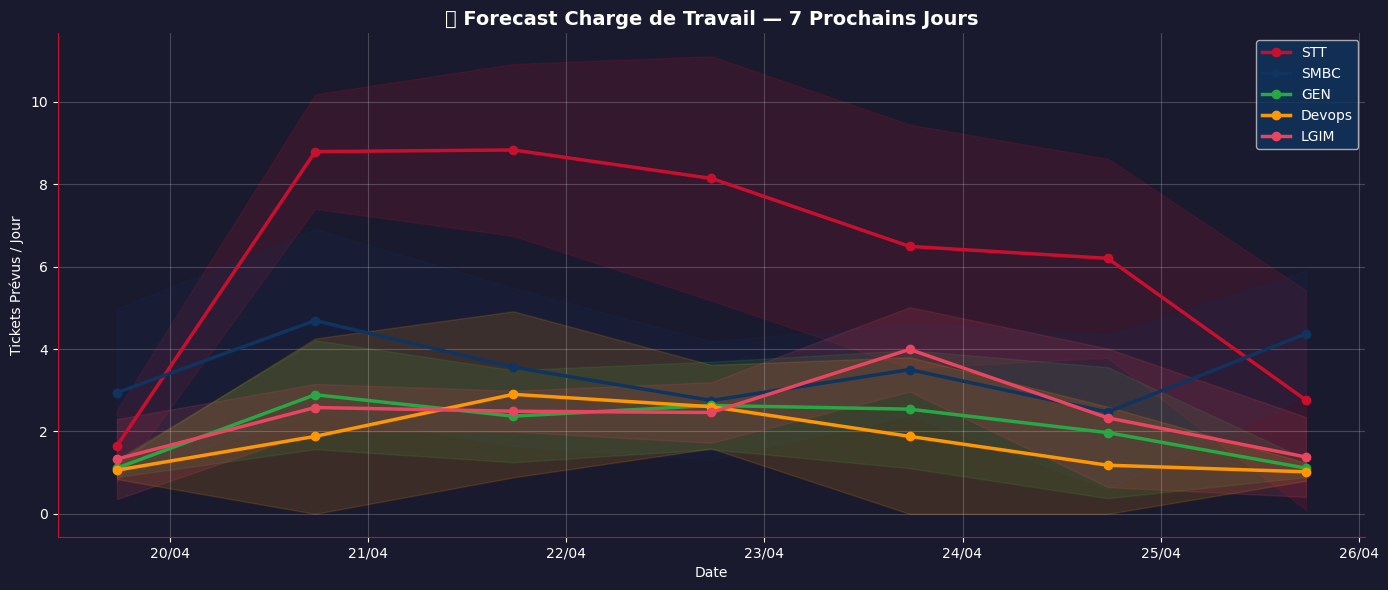

✅ Forecast 7 jours sauvegardé !


In [21]:
# ============================================
# CELLULE — FORECAST 7 JOURS
# ============================================
from datetime import datetime, timedelta
import numpy as np

future_dates = [datetime.today() + timedelta(days=i) for i in range(1, 8)]
top_clients = ['STT', 'SMBC', 'GEN', 'Devops', 'LGIM']

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

colors = ['#C8102E', '#0f3460', '#28a745', '#ff9800', '#e94560']

for i, client in enumerate(top_clients):
    if client not in le.classes_:
        continue
    client_enc = le.transform([client])[0]
    predictions = []
    lower_bound = []
    upper_bound = []

    for future_date in future_dates:
        day_of_week = future_date.weekday()
        month = future_date.month
        week = future_date.isocalendar()[1]
        pred = model_rf.predict([[client_enc, day_of_week, month, week]])[0]
        noise = np.std([
            model_rf.estimators_[j].predict([[client_enc, day_of_week, month, week]])[0]
            for j in range(min(20, len(model_rf.estimators_)))
        ])
        predictions.append(pred)
        lower_bound.append(max(0, pred - noise))
        upper_bound.append(pred + noise)

    ax.plot(future_dates, predictions, color=colors[i], linewidth=2.5,
            marker='o', markersize=6, label=client)
    ax.fill_between(future_dates, lower_bound, upper_bound, alpha=0.15, color=colors[i])

ax.set_title('🔮 Forecast Charge de Travail — 7 Prochains Jours',
             color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', color='white')
ax.set_ylabel('Tickets Prévus / Jour', color='white')
ax.tick_params(colors='white')
ax.legend(loc='upper right', facecolor='#0f3460', labelcolor='white')
ax.grid(True, alpha=0.2, color='white')
ax.spines['bottom'].set_color('#C8102E')
ax.spines['left'].set_color('#C8102E')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.tight_layout()
plt.savefig('forecast_7days.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Forecast 7 jours sauvegardé !")

In [23]:
# ============================================
# CELLULE — API FLASK IA
# ============================================
from flask import Flask, jsonify
from flask_cors import CORS
import threading

app = Flask(__name__)
CORS(app)

@app.route('/ai/health', methods=['GET'])
def health():
    return jsonify({"status": "AI API Running", "version": "2.0"})

@app.route('/ai/predict-workload', methods=['GET'])
def predict_workload():
    results = []
    for client in sorted(le.classes_):
        client_enc = le.transform([client])[0]
        weekly = sum([model_rf.predict([[client_enc, day, 4, 18]])[0] for day in range(5)])
        results.append({
            'client': client,
            'predicted_tickets': round(weekly),
            'predicted_hours': round(weekly * 0.25, 2)
        })
    results.sort(key=lambda x: x['predicted_tickets'], reverse=True)
    return jsonify({
        'predictions': results,
        'total_tickets': sum(r['predicted_tickets'] for r in results),
        'total_hours': round(sum(r['predicted_hours'] for r in results), 2)
    })

@app.route('/ai/detect-anomalies', methods=['GET'])
def detect_anomalies():
    anomalies_list = df_daily[df_daily['is_anomaly']].sort_values('ticket_count', ascending=False)
    return jsonify({
        'total_analyzed': len(df_daily),
        'anomalies_count': len(anomalies_list),
        'anomalies': anomalies_list[['date_only', 'client', 'ticket_count', 'total_hours']].astype(str).to_dict('records')
    })

@app.route('/ai/predict-7days', methods=['GET'])
def predict_7days():
    from datetime import datetime, timedelta
    future_dates = [datetime.today() + timedelta(days=i) for i in range(1, 8)]
    result = []
    for client in sorted(le.classes_):
        client_enc = le.transform([client])[0]
        daily_preds = []
        for future_date in future_dates:
            pred = model_rf.predict([[client_enc, future_date.weekday(), future_date.month, future_date.isocalendar()[1]]])[0]
            daily_preds.append({'date': future_date.strftime('%d/%m'), 'tickets': round(pred, 1)})
        result.append({'client': client, 'predictions': daily_preds})
    return jsonify({'forecast': result})

def run_flask():
    app.run(port=5001, debug=False, use_reloader=False)

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

print("✅ API Flask IA démarrée sur http://localhost:5001")
print("📌 Endpoints :")
print("   GET /ai/health")
print("   GET /ai/predict-workload")
print("   GET /ai/detect-anomalies")
print("   GET /ai/predict-7days")

✅ API Flask IA démarrée sur http://localhost:5001
📌 Endpoints :
   GET /ai/health
   GET /ai/predict-workload
   GET /ai/detect-anomalies
   GET /ai/predict-7days
